### #9

Kaggle competition: [\[link\]](https://www.kaggle.com/competitions/playground-series-s5e9/)

Entry by Robin R.P.M. Kras

robkras.com

### ⭐ 1. Introduction & Overview


Your Goal: The goal of this competition is to predict a song's beats-per-minute.

### 🔹 2. Import Libraries & Set Up


In [1]:
# !/usr/bin/env python3
# -*- coding: utf-8 -*-

# =====================
# General utilities
# =====================
import json
import os
import pickle
import time
from collections import Counter

# =====================
# Data handling & processing
# =====================
import numpy as np
import pandas as pd
from tqdm import tqdm

# =====================
# Visualization
# =====================
import matplotlib.pyplot as plt
import seaborn as sns

# =====================
# Machine Learning - Core scikit-learn
# =====================
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    mean_absolute_error, mean_squared_error, r2_score,
    root_mean_squared_error, roc_auc_score
)
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.svm import SVC, SVR

# =====================
# Machine Learning - Tree Boosting & advanced
# =====================
import xgboost as xg
import lightgbm as lgb
import catboost

# =====================
# Deep Learning - TensorFlow / Keras
# =====================
import tensorflow as tf
from keras import regularizers
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.layers import Dense, Dropout
from keras.models import Sequential
from keras.optimizers import Adam

# =====================
# Deep Learning - PyTorch
# =====================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# =====================
# Imbalanced data handling
# =====================
from imblearn.over_sampling import SMOTE

# =====================
# Optimization / AutoML
# =====================
import optuna

# =====================
# Feature importance & explainability
# =====================
import shap

# =====================
# Self Made Utilities
# =====================
from utils import *

# =====================
# Settings & reproducibility
# =====================
import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

print("Libraries successfully loaded. Ready to go!")

c:\Users\robkr\anaconda3\envs\ml-env-stable\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries successfully loaded. Ready to go!


In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

### 🔹 3. Data Exploration


In [3]:
train.head()

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511


In [4]:
if False: 
    plot_nums(train_engineered.drop(columns=['id']))

In [5]:
numerical_features = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = train.select_dtypes(include=['object', 'category']).columns.tolist
features = train.columns.tolist()

target_col = 'BeatsPerMinute'


🔗 CORRELATION ANALYSIS


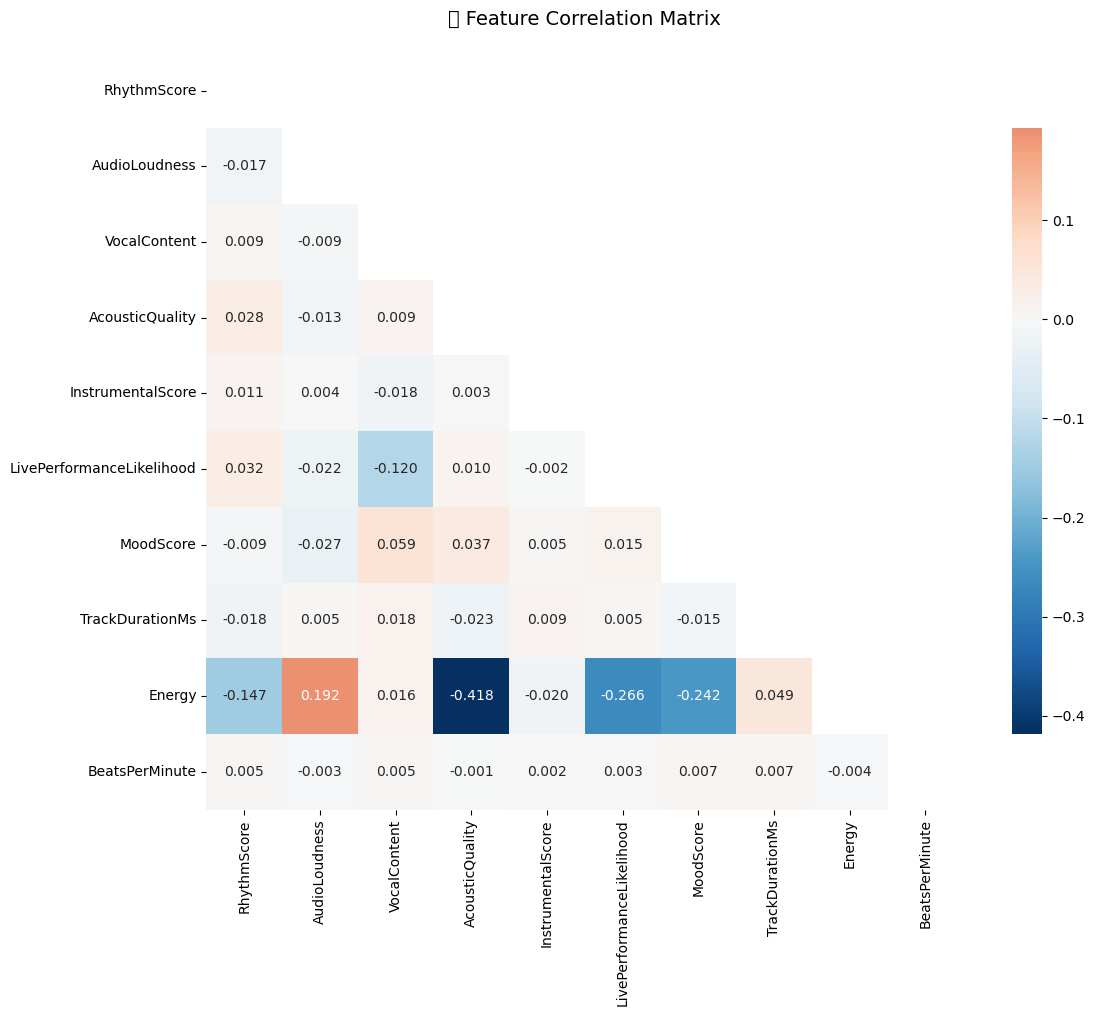


🎯 Features ranked by correlation with BPM:
 1. MoodScore                 | Correlation: 0.0071
 2. TrackDurationMs           | Correlation: 0.0066
 3. RhythmScore               | Correlation: 0.0054
 4. VocalContent              | Correlation: 0.0049
 5. Energy                    | Correlation: 0.0044
 6. LivePerformanceLikelihood | Correlation: 0.0035
 7. AudioLoudness             | Correlation: 0.0033
 8. InstrumentalScore         | Correlation: 0.0019
 9. AcousticQuality           | Correlation: 0.0008


In [6]:
print("\n" + "="*50)
print("🔗 CORRELATION ANALYSIS")
print("="*50)

# Calculate correlation matrix
feature_cols = [col for col in train.columns if col not in ['id', 'BeatsPerMinute']]
correlation_matrix = train[feature_cols + [target_col]].corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdBu_r', 
            center=0, square=True, fmt='.3f', cbar_kws={"shrink": .8})
plt.title('🔗 Feature Correlation Matrix', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Feature importance based on correlation with target
target_correlations = correlation_matrix[target_col].drop(target_col).abs().sort_values(ascending=False)
print("\n🎯 Features ranked by correlation with BPM:")
for i, (feature, corr) in enumerate(target_correlations.items(), 1):
    print(f"{i:2d}. {feature:<25} | Correlation: {corr:.4f}")

### 🔹 4. Feature Engineering

In [15]:
train.head(1)

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0,0.60361,-7.636942,0.0235,0.000005,0.000001,0.051385,0.409866,290715.645,0.826267,147.5302


In [23]:
def engineer_features(df):
    # Create a copy to avoid modifying the original dataframe
    df_new = df.copy()
    
    # 1. Rhythm-based features - BPM is directly related to rhythm
    df_new['Rhythm_Energy'] = df_new['RhythmScore'] * df_new['Energy']
    df_new['Rhythm_Loudness'] = df_new['RhythmScore'] * df_new['AudioLoudness']
    
    # 2. Duration-related features - longer tracks might have different BPM patterns
    df_new['Duration_Minutes'] = df_new['TrackDurationMs'] / 60000  # Convert to minutes
    df_new['Duration_Energy_Ratio'] = df_new['TrackDurationMs'] / (df_new['Energy'] * 10000 + 1)  # Scaled for numerical stability
    
    # 3. Non-linear transformations - capture more complex relationships
    df_new['RhythmScore_Squared'] = df_new['RhythmScore'] ** 2
    df_new['Energy_Squared'] = df_new['Energy'] ** 2
    df_new['Log_Duration'] = np.log1p(df_new['TrackDurationMs'])  # log(1+x) to handle zeros
    
    # 4. Musical character features - representing the "feel" of the song
    df_new['Acoustic_Instrumental_Ratio'] = df_new['AcousticQuality'] / (df_new['InstrumentalScore'] + 0.01)  # Avoid division by zero
    df_new['Vocal_Energy'] = df_new['VocalContent'] * df_new['Energy']
    
    # 5. Performance and mood interactions
    df_new['Live_Energy'] = df_new['LivePerformanceLikelihood'] * df_new['Energy']
    df_new['Mood_Rhythm'] = df_new['MoodScore'] * df_new['RhythmScore']
    
    # 6. Composite metrics
    df_new['Audio_Intensity'] = (df_new['Energy'] * np.abs(df_new['AudioLoudness'])) / 10  # Scaled for better range
    df_new['Performance_Character'] = (df_new['LivePerformanceLikelihood'] + df_new['MoodScore']) / 2
    
    # 7. Ratios that might represent musical balance
    df_new['Energy_Loudness_Ratio'] = df_new['Energy'] / (np.abs(df_new['AudioLoudness']) + 0.01)
    df_new['Rhythm_Duration_Density'] = df_new['RhythmScore'] / df_new['Duration_Minutes']
    
    return df_new

# Apply feature engineering to both train and test sets
train_engineered = engineer_features(train)
test_engineered = engineer_features(test)

# Display the new features
new_features = [col for col in train_engineered.columns if col not in train.columns]
print(f"Created {len(new_features)} new features:")
print(new_features)

# Check correlation of new features with the target
new_feature_correlation = train_engineered[new_features + ['BeatsPerMinute']].corr()['BeatsPerMinute'].sort_values(ascending=False)
print("\nNew Feature Correlation with BPM:")
print(new_feature_correlation)

Created 15 new features:
['Rhythm_Energy', 'Rhythm_Loudness', 'Duration_Minutes', 'Duration_Energy_Ratio', 'RhythmScore_Squared', 'Energy_Squared', 'Log_Duration', 'Acoustic_Instrumental_Ratio', 'Vocal_Energy', 'Live_Energy', 'Mood_Rhythm', 'Audio_Intensity', 'Performance_Character', 'Energy_Loudness_Ratio', 'Rhythm_Duration_Density']

New Feature Correlation with BPM:
BeatsPerMinute                 1.000000
Mood_Rhythm                    0.009362
Performance_Character          0.007814
Duration_Minutes               0.006637
Log_Duration                   0.006302
RhythmScore_Squared            0.004853
Live_Energy                    0.000893
Vocal_Energy                   0.000365
Audio_Intensity               -0.000832
Duration_Energy_Ratio         -0.001208
Rhythm_Energy                 -0.001630
Rhythm_Duration_Density       -0.001712
Acoustic_Instrumental_Ratio   -0.001906
Energy_Squared                -0.004072
Energy_Loudness_Ratio         -0.004479
Rhythm_Loudness             

### 🔹 5. Model Testing and Submission

In [24]:
# Analyze correlations with new features
numerical_features = train_engineered.select_dtypes(include=[np.number]).columns
numerical_features = [col for col in numerical_features if col not in ['id']]

new_correlations = train_engineered[numerical_features].corr()[target_col].drop(target_col).abs().sort_values(ascending=False)

print(f"\n🔥 Top 15 Features by Correlation with BPM:")
for i, (feature, corr) in enumerate(new_correlations.head(15).items(), 1):
    print(f"{i:2d}. {feature:<30} | Correlation: {corr:.4f}")


🔥 Top 15 Features by Correlation with BPM:
 1. Mood_Rhythm                    | Correlation: 0.0094
 2. Performance_Character          | Correlation: 0.0078
 3. MoodScore                      | Correlation: 0.0071
 4. TrackDurationMs                | Correlation: 0.0066
 5. Duration_Minutes               | Correlation: 0.0066
 6. Log_Duration                   | Correlation: 0.0063
 7. RhythmScore                    | Correlation: 0.0054
 8. VocalContent                   | Correlation: 0.0049
 9. RhythmScore_Squared            | Correlation: 0.0049
10. Rhythm_Loudness                | Correlation: 0.0045
11. Energy_Loudness_Ratio          | Correlation: 0.0045
12. Energy                         | Correlation: 0.0044
13. Energy_Squared                 | Correlation: 0.0041
14. LivePerformanceLikelihood      | Correlation: 0.0035
15. AudioLoudness                  | Correlation: 0.0033


In [25]:
train_engineered.head(1)

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,...,Energy_Squared,Log_Duration,Acoustic_Instrumental_Ratio,Vocal_Energy,Live_Energy,Mood_Rhythm,Audio_Intensity,Performance_Character,Energy_Loudness_Ratio,Rhythm_Duration_Density
0,0,0.60361,-7.636942,0.0235,0.000005,0.000001,0.051385,0.409866,290715.645,0.826267,...,0.682717,12.580104,0.000536,0.019417,0.042458,0.247399,0.631015,0.230626,0.108052,0.124577


In [26]:
# Prepare features for modeling
feature_columns = [col for col in numerical_features if col != target_col]
X = train_engineered[feature_columns]
y = train_engineered[target_col]

print(f"📊 Training with {len(feature_columns)} features")
print(f"🎯 Target variable: {target_col}")

# Split the data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

📊 Training with 24 features
🎯 Target variable: BeatsPerMinute


From a post on the forum I found that XGBoost, LightGBM, and Ridge perform the best. Let's make a meta model and an ensemble.

In [27]:
def evaluate_model(model, X_tr, y_tr, X_v, y_v, model_name):
    """Evaluate a model and return metrics"""
    model.fit(X_tr, y_tr)
    
    # Predictions
    train_pred = model.predict(X_tr)
    val_pred = model.predict(X_v)
    
    # Metrics
    train_rmse = np.sqrt(mean_squared_error(y_tr, train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_v, val_pred))
    val_r2 = r2_score(y_v, val_pred)
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=5, 
                               scoring='neg_root_mean_squared_error')
    cv_rmse = -cv_scores.mean()
    cv_std = cv_scores.std()
    
    return {
        'model_name': model_name,
        'train_rmse': train_rmse,
        'val_rmse': val_rmse,
        'val_r2': val_r2,
        'cv_rmse': cv_rmse,
        'cv_std': cv_std,
        'model': model
    }

# Define models to test
models = {
    'XGBoost': xg.XGBRegressor(random_state=42, n_jobs=-1),
    'LightGBM': lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    'Ridge': Ridge(alpha=1.0),
    'CatBoost': catboost.CatBoostRegressor(random_state=42, verbose=0),
    'KNN': KNeighborsRegressor(n_neighbors=5),
}

# Evaluate all models
results = []
print("🚀 Training and evaluating models...")

for name, model in models.items():
    print(f"   Training {name}...")
    if name in ['Ridge', 'KNN']:
        result = evaluate_model(model, X_train_scaled, y_train, X_val_scaled, y_val, name)
    else:
        result = evaluate_model(model, X_train, y_train, X_val, y_val, name)
    results.append(result)

# Create results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('val_rmse')

print("\n🏆 MODEL PERFORMANCE COMPARISON")
print("="*70)
for _, row in results_df.iterrows():
    print(f"{row['model_name']:<15} | Val RMSE: {row['val_rmse']:.4f} | "
          f"CV RMSE: {row['cv_rmse']:.4f} ± {row['cv_std']:.4f} | R²: {row['val_r2']:.4f}")

🚀 Training and evaluating models...
   Training XGBoost...
   Training LightGBM...
   Training Ridge...
   Training CatBoost...
   Training KNN...

🏆 MODEL PERFORMANCE COMPARISON
Ridge           | Val RMSE: 26.4435 | CV RMSE: 26.4719 ± 0.0514 | R²: 0.0001
LightGBM        | Val RMSE: 26.4458 | CV RMSE: 26.4768 ± 0.0541 | R²: -0.0000
CatBoost        | Val RMSE: 26.4865 | CV RMSE: 26.5289 ± 0.0566 | R²: -0.0031
XGBoost         | Val RMSE: 26.5309 | CV RMSE: 26.6046 ± 0.0585 | R²: -0.0065
KNN             | Val RMSE: 28.9371 | CV RMSE: 28.9917 ± 0.0782 | R²: -0.1973


In [29]:
def objective_xgboost(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'subsample': trial.suggest_float('subsample', 0.5, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 2.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 5.0),
        'gamma': trial.suggest_float('gamma', 0.0, 1.0),
        'random_state': 42,
        'eval_metric': 'rmse',
        'early_stopping_rounds': 100,
        'verbosity': 0
    }

    # 5-fold CV for faster tuning
    cv_scores = []
    kf_tune = KFold(n_splits=5, shuffle=True, random_state=42)

    for train_idx, val_idx in kf_tune.split(X, y):
        X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
        X_val_fold, y_val_fold = X.iloc[val_idx], y.iloc[val_idx]

        model = xg.XGBRegressor(**params)
        model.fit(X_train_fold, y_train_fold, eval_set=[(X_val_fold, y_val_fold)], verbose=False)

        pred = model.predict(X_val_fold)
        score = root_mean_squared_error(y_val_fold, pred)
        cv_scores.append(score)

    return np.mean(cv_scores)

print("➗ Tuning XGBoost parameters...")
study_xgboost = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))       
study_xgboost.optimize(objective_xgboost, n_trials=50)

best_xgboost_params = study_xgboost.best_params
print(f"Best XGBoost CV RMSE: {study_xgboost.best_value:.4f}")
print(f"Best XGBoost params: {best_xgboost_params}")

[I 2025-09-22 16:29:08,291] A new study created in memory with name: no-name-dfbabfe6-4ab2-439a-9bd3-3aeb5c28345f


➗ Tuning XGBoost parameters...


[I 2025-09-22 16:29:22,424] Trial 0 finished with value: 26.4642200017243 and parameters: {'n_estimators': 193, 'learning_rate': 0.09556428757689246, 'max_depth': 7, 'min_child_weight': 5, 'subsample': 0.5624074561769746, 'colsample_bytree': 0.562397808134481, 'reg_alpha': 0.21035886311957896, 'reg_lambda': 4.46470458309974, 'gamma': 0.6011150117432088}. Best is trial 0 with value: 26.4642200017243.
[I 2025-09-22 16:29:54,998] Trial 1 finished with value: 26.461946122867015 and parameters: {'n_estimators': 357, 'learning_rate': 0.011852604486622221, 'max_depth': 8, 'min_child_weight': 6, 'subsample': 0.5849356442713105, 'colsample_bytree': 0.5727299868828403, 'reg_alpha': 0.4484685687215243, 'reg_lambda': 2.216968971838151, 'gamma': 0.5247564316322378}. Best is trial 1 with value: 26.461946122867015.
[I 2025-09-22 16:30:15,221] Trial 2 finished with value: 26.46107597288878 and parameters: {'n_estimators': 222, 'learning_rate': 0.036210622617823776, 'max_depth': 6, 'min_child_weight': 

Best XGBoost CV RMSE: 26.4601
Best XGBoost params: {'n_estimators': 295, 'learning_rate': 0.0567613675005883, 'max_depth': 4, 'min_child_weight': 3, 'subsample': 0.7675628372337775, 'colsample_bytree': 0.7507986003881107, 'reg_alpha': 0.47931992928038936, 'reg_lambda': 2.4811452579774658, 'gamma': 0.8416584722982138}


Best XGBoost CV RMSE: 26.4604


7 features = 26.4602


In [ ]:
def objective_lightgbm(trial):
    # LightGBM-specific parameter space for regression
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 500),       
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),   
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'num_leaves': trial.suggest_int('num_leaves', 31, 127),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 2.0),
        'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 1.0),
        'random_state': 42,
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
        'early_stopping_rounds': 100
    }

    # 5-fold CV for faster tuning
    cv_scores = []
    kf_tune = KFold(n_splits=5, shuffle=True, random_state=42)

    for train_idx, val_idx in kf_tune.split(X, y):
        X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
        X_val_fold, y_val_fold = X.iloc[val_idx], y.iloc[val_idx]

        model = lgb.LGBMRegressor(**params)
        model.fit(X_train_fold, y_train_fold, eval_set=[(X_val_fold, y_val_fold)])

        pred = model.predict(X_val_fold)
        score = root_mean_squared_error(y_val_fold, pred)
        cv_scores.append(score)

    return np.mean(cv_scores)

if False:

    print("Tuning LightGBM parameters...")
    study_lightgbm = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
    study_lightgbm.optimize(objective_lightgbm, n_trials=50)

    best_lightgbm_params = study_lightgbm.best_params
    print(f"Best LightGBM CV RMSE: {study_lightgbm.best_value:.4f}")
    print(f"Best LightGBM params: {best_lightgbm_params}")

In [41]:
# Apply same feature engineering
test_engineered = engineer_features(test)

# Prepare test features
X_test = test_engineered[feature_columns]

# Define the ensemble models (these need to be trained first)
best_models = {
    'XGBoost': xg.XGBRegressor(**best_xgboost_params, random_state=42, n_jobs=-1),
    'Ridge': Ridge(alpha=1.0)
}

# Train the models on full training data
print("Training ensemble models on full dataset...")

# Train XGBoost
best_models['XGBoost'].fit(X_train, y_train)

# Train Ridge (using scaled features)
X_train_scaled = scaler.fit_transform(X_train)
best_models['Ridge'].fit(X_train_scaled, y_train)

# Make predictions using ensemble
weights = {'XGBoost': 0.4, 'Ridge': 0.6}  # XGBoost: 40%, Ridge: 60%
test_predictions = np.zeros(len(X_test))

print("Making ensemble predictions...")

for model_name, model in best_models.items():
    weight = weights[model_name]
    
    if model_name == 'Ridge':
        # Ridge uses scaled features
        X_test_scaled = scaler.transform(X_test)
        pred = model.predict(X_test_scaled)
    else:
        # XGBoost uses original features
        pred = model.predict(X_test)
    
    test_predictions += weight * pred
    print(f"   {weight*100:2.0f}% {model_name} predictions added")

# Create submission DataFrame
submission = pd.DataFrame({
    'id': test['id'],
    'BeatsPerMinute': test_predictions
})

print(f"\n✅ Submission created with {len(submission)} predictions")
print(f"Prediction range: {test_predictions.min():.2f} - {test_predictions.max():.2f}")

rmse = np.sqrt(mean_squared_error(y_val, (weights['XGBoost'] * best_models['XGBoost'].predict(X_val) + weights['Ridge'] * best_models['Ridge'].predict(X_val_scaled))))
print(f"Ensemble Validation RMSE: {rmse:.4f}")

Training ensemble models on full dataset...
Making ensemble predictions...
   40% XGBoost predictions added
   60% Ridge predictions added

✅ Submission created with 174722 predictions
Prediction range: 114.60 - 123.59
Ensemble Validation RMSE: 26.4411


In [42]:
submission.to_csv('submission-not-blended.csv', index=False)

In [43]:
submission.head()

,id,BeatsPerMinute
0,524164,119.102017
1,524165,118.853415
2,524166,119.899462
3,524167,119.390815
4,524168,119.492375


In [44]:
def generate_stack(
    base_models,
    X, y,
    X_test,
    meta_model=None,
    folds=5,
    seed=42,
    eval_metric=root_mean_squared_error
):
    """
    Train a stacking ensemble.

    Parameters:
    - base_models: list of sklearn-like models (must implement fit & predict)
    - X, y: training data
    - X_test: test data (for generating meta features)
    - meta_model: sklearn-like model for meta learning (default: LinearRegression)
    - folds: number of KFold splits
    - seed: random seed for reproducibility
    - eval_metric: function to evaluate final stacked predictions (default: RMSE)

    Returns:
    - meta_model: trained meta-model
    - meta_features_train: level-one train predictions
    - meta_features_test: level-one test predictions
    - final_score: score computed by eval_metric
    """

    n_models = len(base_models)
    meta_features_train = np.zeros((len(X), n_models))
    meta_features_test = np.zeros((len(X_test), n_models))
    
    kf = KFold(n_splits=folds, shuffle=True, random_state=seed)

    print(f"Starting stacking with {n_models} base models and {folds}-fold CV...")
    
    for i, model in enumerate(base_models):
        print(f"\nTraining model {i+1}/{n_models}: {model.__class__.__name__}")
        
        oof = np.zeros(len(X))
        preds = np.zeros(len(X_test))
        
        for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

            model.fit(X_train, y_train)
            oof[val_idx] = model.predict(X_val)
            preds += model.predict(X_test) / folds

            fold_score = eval_metric(y_val, oof[val_idx])
            print(f"  Fold {fold+1} {eval_metric.__name__}: {fold_score:.4f}")

        meta_features_train[:, i] = oof
        meta_features_test[:, i] = preds
    
    # Use default meta model if none provided
    if meta_model is None:
        meta_model = LinearRegression()

    print(f"\nFitting meta-model: {meta_model.__class__.__name__}")
    meta_model.fit(meta_features_train, y)
    
    stacked_preds = meta_model.predict(meta_features_train)
    final_score = eval_metric(y, stacked_preds)
    print(f"\nFinal cross-validation {eval_metric.__name__}: {final_score:.4f}")

    return meta_model, meta_features_train, meta_features_test, final_score

meta_model, meta_features_train, meta_features_test, final_score = generate_stack(
    base_models=[
        lgb.LGBMRegressor( n_estimators=100,),
        xg.XGBRegressor(**best_xgboost_params,),
        Ridge(alpha=1.0)
    ],
    X=X,
    y=y,
    X_test=X_test,
    meta_model=Ridge(alpha=1.0),
    folds=5,
    seed=42,
    eval_metric=root_mean_squared_error
)

Starting stacking with 3 base models and 5-fold CV...

Training model 1/3: LGBMRegressor
  Fold 1 root_mean_squared_error: 26.4442
  Fold 2 root_mean_squared_error: 26.4943
  Fold 3 root_mean_squared_error: 26.5276
  Fold 4 root_mean_squared_error: 26.4485
  Fold 5 root_mean_squared_error: 26.4165

Training model 2/3: XGBRegressor
  Fold 1 root_mean_squared_error: 26.4485
  Fold 2 root_mean_squared_error: 26.4927
  Fold 3 root_mean_squared_error: 26.5304
  Fold 4 root_mean_squared_error: 26.4494
  Fold 5 root_mean_squared_error: 26.4132

Training model 3/3: Ridge
  Fold 1 root_mean_squared_error: 26.4435
  Fold 2 root_mean_squared_error: 26.4906
  Fold 3 root_mean_squared_error: 26.5286
  Fold 4 root_mean_squared_error: 26.4520
  Fold 5 root_mean_squared_error: 26.4154

Fitting meta-model: Ridge

Final cross-validation root_mean_squared_error: 26.4612


In [46]:
test_predictions = meta_model.predict(meta_features_test)

submission = pd.DataFrame({
    'id': test['id'],
    'BeatsPerMinute': test_predictions
})

submission.to_csv('submission-stacked.csv', index=False)

In [45]:
submission.head()

,id,BeatsPerMinute
0,524164,119.102017
1,524165,118.853415
2,524166,119.899462
3,524167,119.390815
4,524168,119.492375
